In [1]:
import sys
print(sys.executable)
print(sys.version)


C:\Users\fares\anaconda3\envs\pycaret-env\python.exe
3.11.13 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:03:15) [MSC v.1929 64 bit (AMD64)]


In [2]:
import pandas as pd
df = pd.read_csv("C:/Users/fares/Desktop/LaPlateforme/IA/Bank Marketing/bank-marketing/data/bank-additional-full.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
X = df.drop("y", axis=1)
y = df["y"]

In [4]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [5]:
df.apply(lambda col: col.isin(["unknown"]).sum())

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [6]:
df = df.replace("unknown", "missing")

In [7]:
df.apply(lambda col: col.isin(["unknown"]).sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [8]:
import numpy
import scipy
print(numpy.__version__)
print(scipy.__version__)


1.26.4
1.10.1


In [9]:
from pycaret.classification import *
setup(data=df, target='y')


,Description,Value
0,Session id,521
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(41188, 21)"
5,Transformed data shape,"(41188, 63)"
6,Transformed train set shape,"(28831, 63)"
7,Transformed test set shape,"(12357, 63)"
8,Numeric features,10
9,Categorical features,10


Recherche de mineurs

In [11]:
(df["age"] < 18).sum()


5

On affiche les 5 pour avoir toutes leur données

In [13]:
df[df["age"] < 18]


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
37140,17,student,single,missing,no,yes,no,cellular,aug,wed,...,3,4,2,success,-2.9,92.201,-31.4,0.884,5076.2,no
37539,17,student,single,basic.9y,no,yes,no,cellular,aug,fri,...,2,999,2,failure,-2.9,92.201,-31.4,0.869,5076.2,no
37558,17,student,single,basic.9y,no,yes,no,cellular,aug,fri,...,3,4,2,success,-2.9,92.201,-31.4,0.869,5076.2,no
37579,17,student,single,basic.9y,no,missing,missing,cellular,aug,fri,...,2,999,1,failure,-2.9,92.201,-31.4,0.869,5076.2,yes
38274,17,student,single,missing,no,no,yes,cellular,oct,tue,...,1,2,2,success,-3.4,92.431,-26.9,0.742,5017.5,yes


5 individus âgés de 17 ans ont été détectés. Bien que l’ouverture d’un compte soit possible avec autorisation parentale, le démarchage actif pour un produit financier (dépôt à terme) sans consentement explicite n’est pas légalement autorisé. Nous avons donc choisi de les exclure par précaution

In [15]:
df = df[df["age"] >= 18]

On verifie que c'est bien supprimer

In [17]:
(df["age"] < 18).sum()

0

In [18]:
from pycaret.classification import *

setup(data=df, target='y', session_id=123)


,Description,Value
0,Session id,123
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(41183, 21)"
5,Transformed data shape,"(41183, 63)"
6,Transformed train set shape,"(28828, 63)"
7,Transformed test set shape,"(12355, 63)"
8,Numeric features,10
9,Categorical features,10


In [19]:
best_model = compare_models()


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9156,0.9458,0.9156,0.9085,0.9107,0.5303,0.5363,0.8530
lightgbm,Light Gradient Boosting Machine,0.9150,0.9491,0.9150,0.9099,0.9118,0.5434,0.5463,0.3780
rf,Random Forest Classifier,0.9116,0.9396,0.9116,0.9016,0.9037,0.4833,0.4953,0.4580
lr,Logistic Regression,0.9103,0.9319,0.9103,0.8991,0.9008,0.4623,0.4784,1.3610
lda,Linear Discriminant Analysis,0.9089,0.9330,0.9089,0.9024,0.9048,0.5045,0.5080,0.2070
ada,Ada Boost Classifier,0.9084,0.9367,0.9084,0.8966,0.8987,0.4501,0.4662,0.3880
ridge,Ridge Classifier,0.9068,0.9330,0.9068,0.8927,0.8916,0.3941,0.4271,0.1390
knn,K Neighbors Classifier,0.9038,0.8720,0.9038,0.8967,0.8995,0.4765,0.4799,0.6910
et,Extra Trees Classifier,0.9014,0.9143,0.9014,0.8864,0.8891,0.3916,0.4110,0.6090
dt,Decision Tree Classifier,0.8907,0.7323,0.8907,0.8920,0.8913,0.4592,0.4595,0.1690


In [20]:
print(best_model)

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=123, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


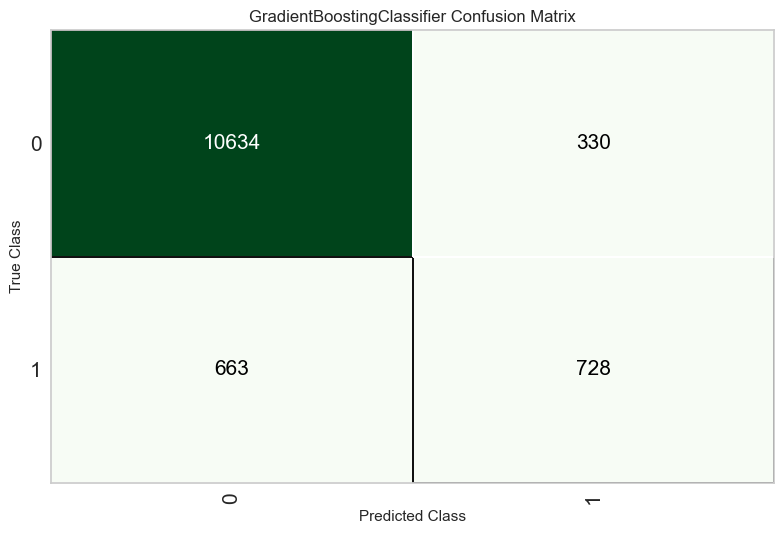

In [21]:
plot_model(best_model, plot='confusion_matrix')

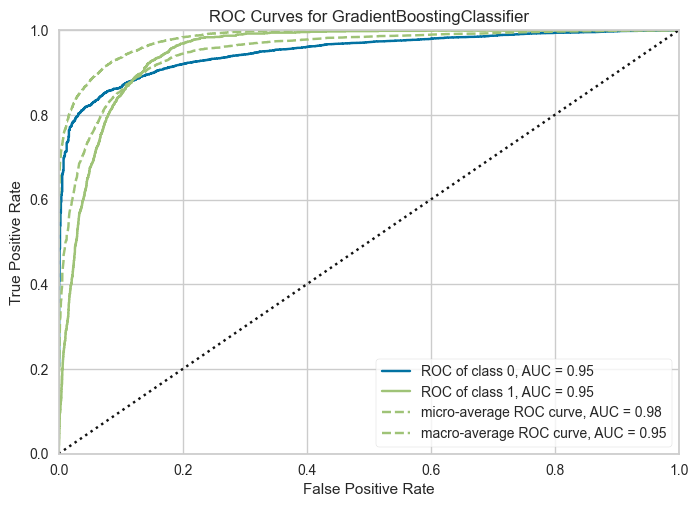

In [22]:
plot_model(best_model, plot='auc')

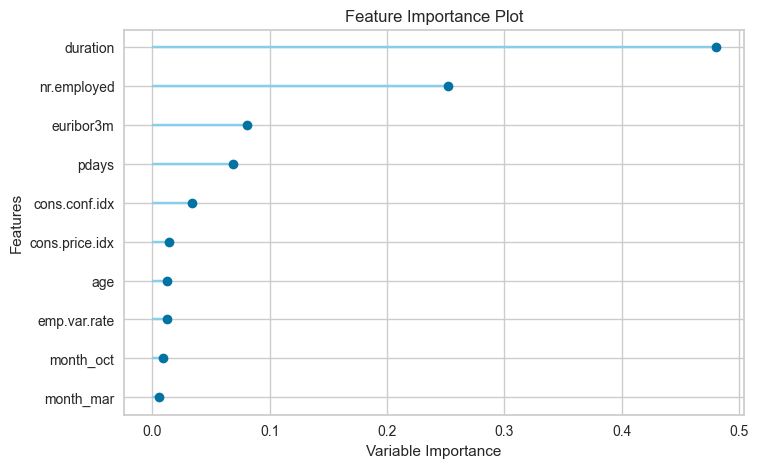

In [23]:
plot_model(best_model, plot='feature')

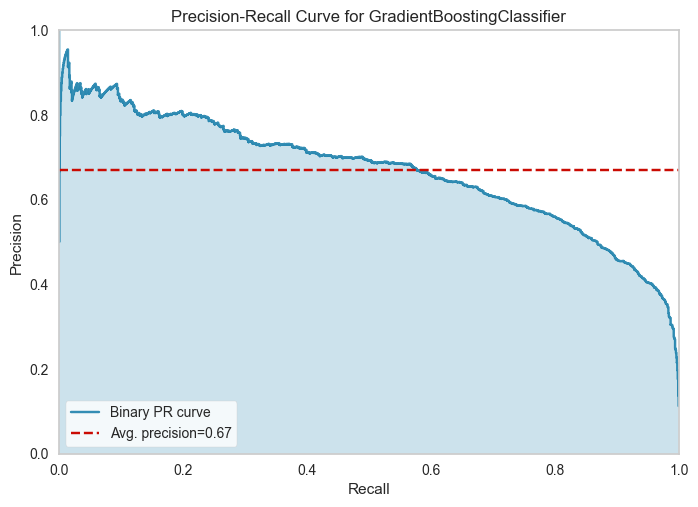

In [24]:
plot_model(best_model, plot='pr')

In [47]:
df["duration"].head(100)

0     261
1     149
2     226
3     151
4     307
     ... 
95    221
96    426
97    287
98    197
99    257
Name: duration, Length: 100, dtype: int64

In [49]:
df.groupby("y")["duration"].mean()

y
no     220.843617
yes    553.129150
Name: duration, dtype: float64